In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show_image(title, img, cmap=None):
    plt.figure(figsize=(6, 6))
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis('off')
    plt.show()

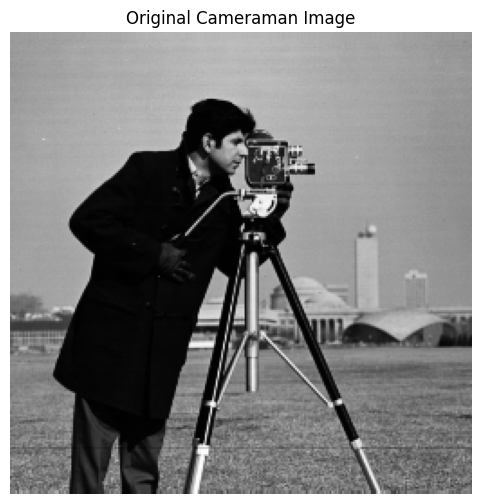

In [ ]:
img = cv2.imread('../lab-3/cameraman.png', cv2.IMREAD_GRAYSCALE)
show_image('Original Cameraman Image', img, cmap='gray')

In [ ]:
sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])

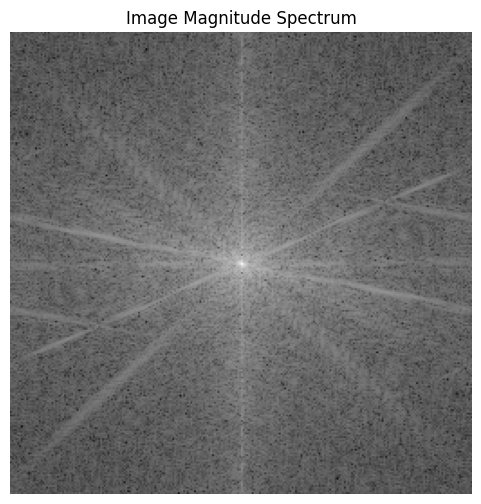

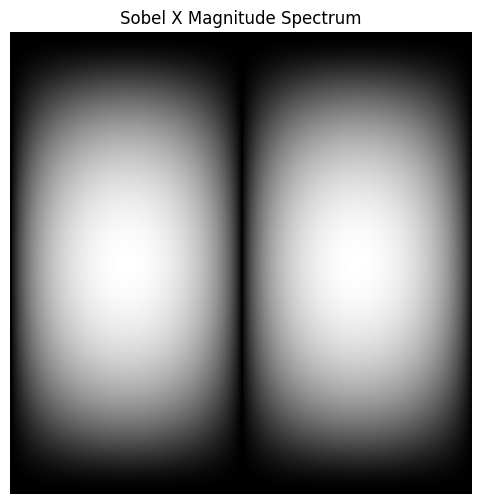

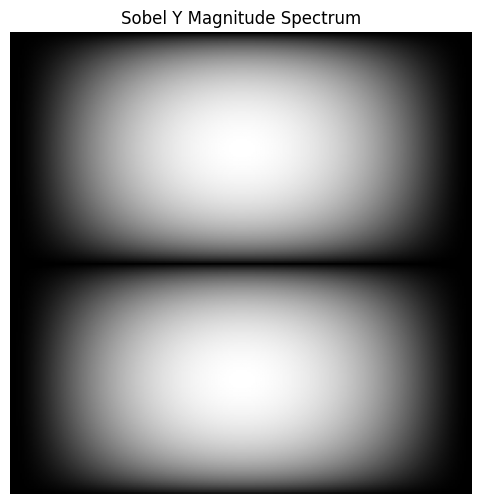

In [ ]:
rows, cols = img.shape
padded_sobel_x = np.zeros((rows, cols))
padded_sobel_y = np.zeros((rows, cols))
padded_sobel_x[:3, :3] = sobel_x
padded_sobel_y[:3, :3] = sobel_y

img_fft = np.fft.fft2(img)
sobel_x_fft = np.fft.fft2(padded_sobel_x)
sobel_y_fft = np.fft.fft2(padded_sobel_y)

img_fft_shifted = np.fft.fftshift(img_fft)
sobel_x_fft_shifted = np.fft.fftshift(sobel_x_fft)
sobel_y_fft_shifted = np.fft.fftshift(sobel_y_fft)

magnitude_spectrum_img = 20 * np.log(np.abs(img_fft_shifted))
magnitude_spectrum_sobel_x = 20 * np.log(np.abs(sobel_x_fft_shifted) + 1) # Add 1 to avoid log(0)
magnitude_spectrum_sobel_y = 20 * np.log(np.abs(sobel_y_fft_shifted) + 1) # Add 1 to avoid log(0)

show_image('Image Magnitude Spectrum', magnitude_spectrum_img, cmap='gray')
show_image('Sobel X Magnitude Spectrum', magnitude_spectrum_sobel_x, cmap='gray')
show_image('Sobel Y Magnitude Spectrum', magnitude_spectrum_sobel_y, cmap='gray')


In [ ]:
filtered_x_fft = img_fft * sobel_x_fft
filtered_y_fft = img_fft * sobel_y_fft

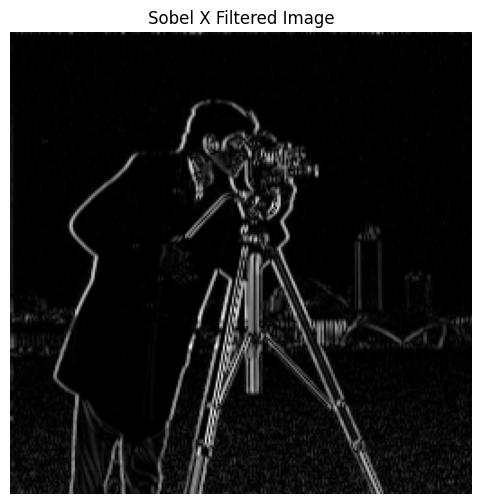

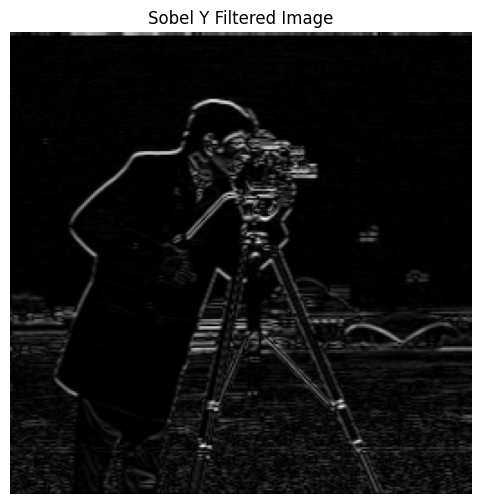

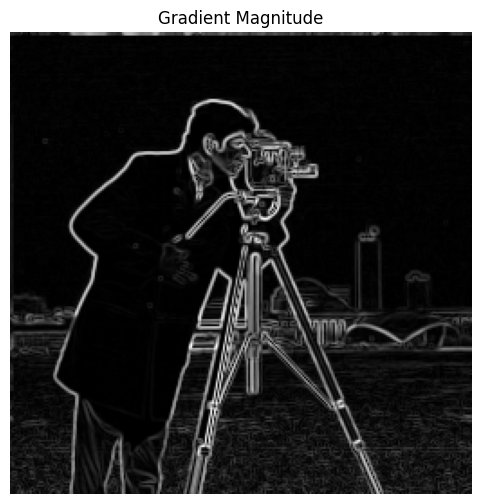

In [ ]:
filtered_img_x = np.fft.ifft2(filtered_x_fft)
filtered_img_y = np.fft.ifft2(filtered_y_fft)

filtered_img_x = np.abs(filtered_img_x)
filtered_img_y = np.abs(filtered_img_y)

show_image('Sobel X Filtered Image', filtered_img_x, cmap='gray')
show_image('Sobel Y Filtered Image', filtered_img_y, cmap='gray')

# Combine the two gradients
gradient_magnitude = np.sqrt(filtered_img_x**2 + filtered_img_y**2)
show_image('Gradient Magnitude', gradient_magnitude, cmap='gray')